In [4]:
import numpy as np #linear algebra
import pandas as pd #data processing
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib

from plotly.offline import init_notebook_mode, iplot
init_notebook_mode(connected=True)


Reading And Displaying The Dataset

In [5]:
#Dataset Reading

DATASET_PATH = "../data/SQLiV3.csv"

df = pd.read_csv(DATASET_PATH, encoding="UTF-8")

df.head(10)#gives first 10 rows of the dataset



,Sentence,Label,Unnamed: 2,Unnamed: 3
0,""" or pg_sleep ( __TIME__ ) --",1,NaN,NaN
1,create user name identified by pass123 tempora...,NaN,1,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1,NaN,NaN
3,select * from users where id = '1' or @ @1 ...,1,NaN,NaN
4,"select * from users where id = 1 or 1#"" ( ...",1,NaN,NaN
5,select name from syscolumns where id = ...,1,NaN,NaN
6,select * from users where id = 1 +$+ or 1 =...,1,NaN,NaN
7,"1; ( load_file ( char ( 47,101,116,99,47...",1,NaN,NaN
8,select * from users where id = '1' or ||/1 ...,1,NaN,NaN
9,select * from users where id = '1' or \.<\ ...,1,NaN,NaN


Data PreProcessing

In [6]:
#Removing Unwanted Columns

df = df.drop(columns=['Unnamed: 2','Unnamed: 3']) # Removing Unnamed Columns and Copying into df

df.shape

(30919, 2)

In [7]:
df.head()

,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
1,create user name identified by pass123 tempora...,NaN
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1


In [8]:
print("----------------------------------------------------")
df.info()
print("----------------------------------------------------")

----------------------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 30919 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Sentence  30904 non-null  str  
 1   Label     30664 non-null  str  
dtypes: str(2)
memory usage: 483.2 KB
----------------------------------------------------


In [9]:
df['Label'].describe()
#Count is non null values
#Unique is unique values
#Top is most frequent value
#Freq is frequency of the top value



count     30664
unique       42
top           0
freq      19268
Name: Label, dtype: object

In [10]:
df['Label'].isna().sum()
#Count NaN Label values

df.dropna(subset=['Label'], inplace=True)
#Dropping NaN Label values and Copying into df

In [11]:
df['Label'].isna().sum()

np.int64(0)

In [12]:
#Getting Unique Values
unique_values = df['Label'].unique()
print('\n'.join(l for l in unique_values))
#print(unique_values)

1
 if not  (  select system_user  )   <> 'sa' waitfor delay '0:0:2' --
 execute immediate 'sel' || 'ect us' || 'er'
 exec xp_regread
SELECT *
 --
 desc users
 OR
 exec master..xp_cmdshell 'ping 172.10.1.255'--
 exec master..xp_cmdshell
 if is_srvrolemember  (  'sysadmin'  )   > 0 waitfor delay '0:0:2' --
waitfor delay '0:0:__TIME__'--
 exec   (  'sel' + 'ect us' + 'er'  ) 
 drop table temp --
 if not   (    (   select serverproperty  (  'isintegratedsecurityonly'   )    )    <> 0  )   waitfor delay '0:0:2' --
 exec master..xp_cmdshell 'ping 10.10.1.2'--
 if not   (    (   select serverproperty  (  'isintegratedsecurityonly'   )    )    <> 1  )   waitfor delay '0:0:2' --
 begin declare @var varchar  (  8000  )   set @var  =  ':' select @var  =  @var+'+login+'/'+password+' ' from users where login >
 or '1'  =  '1'
 begin declare @var varchar  (  8000  )   set @var  =  ' ...
0
 grant resource to name
s
 EXEC SelectAllCustomers
 /*Select all the columns of all the records in the Customers

In [13]:
#Dropping Unique Labels Which is not 0 or 1
df = df.drop(df[(df['Label'] != '0') & (df['Label'] != '1')].index)

In [14]:
df['Label'].unique()

<StringArray>
['1', '0']
Length: 2, dtype: str

In [15]:
df['Label'].describe()

count     30609
unique        2
top           0
freq      19268
Name: Label, dtype: object

In [16]:
df.head(100)

,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1
5,select name from syscolumns where id = ...,1
...,...,...
97,AND 1 = utl_inaddr.get_host_address ( ...,1
98,or 1 = 1 or '' = ',1
99,select * from users where id = 1 or 1 = ...,1
100,or 'text' > 't',1


Converting Data Type

In [17]:
#Converting Data Type
df['Label'] = df['Label'].astype(int)

In [18]:
df.info()

<class 'pandas.DataFrame'>
Index: 30609 entries, 0 to 30918
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   Sentence  30609 non-null  str  
 1   Label     30609 non-null  int64
dtypes: int64(1), str(1)
memory usage: 717.4 KB


In [19]:
#Count of how many 1 and 0 in the Label column
df['Label'].value_counts()


Label
0    19268
1    11341
Name: count, dtype: int64

Distrubition Of Label

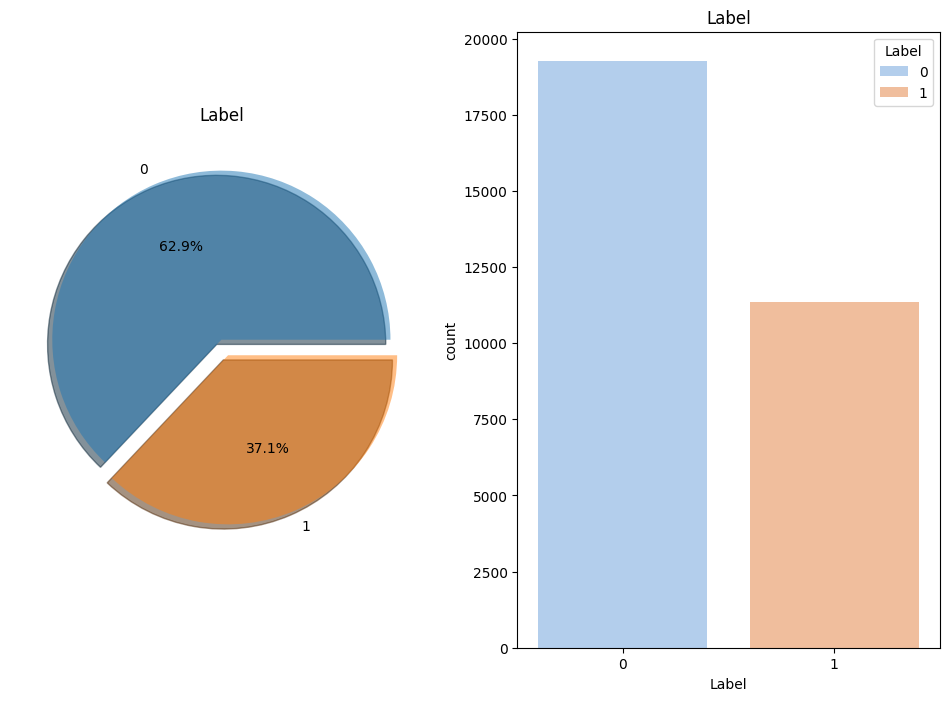

In [20]:
f, ax=plt.subplots(1,2, figsize=(12,8))
#making 2 subplots 1 row 2 columns
#f is figure and ax is axis

df['Label'].value_counts().plot.pie(explode=[0,0.1],autopct='%1.1f%%',ax=ax[0],shadow=True,wedgeprops={'alpha':0.5})
#making exploding pie chart


ax[0].set_title('Label')
ax[0].set_ylabel('')

sns.countplot(x='Label', data=df, ax=ax[1], alpha=0.9, hue='Label', palette='pastel')
#making countplot of data at x axis with seaborn
ax[1].set_title('Label')
plt.show()

Content of the Data

In [21]:
df.head()

,Sentence,Label
0,""" or pg_sleep ( __TIME__ ) --",1
2,AND 1 = utl_inaddr.get_host_address ( ...,1
3,select * from users where id = '1' or @ @1 ...,1
4,"select * from users where id = 1 or 1#"" ( ...",1
5,select name from syscolumns where id = ...,1


In [22]:
#How many comment symbols are in payloads?
comment_values= df[df.Sentence.str.contains('#|--|//')]
print(comment_values)

                                                Sentence  Label
0                      " or pg_sleep  (  __TIME__  )  --      1
3       select * from users where id  =  '1' or @ @1 ...      1
4       select * from users where id  =  1 or 1#"  ( ...      1
5       select name from syscolumns where id   =     ...      1
6      select * from users where id  =  1 +$+ or 1  =...      1
...                                                  ...    ...
19330                                  â or 1  =  1 --      1
19334                                      or 3  =  3 --      1
19337  0" encoding  =  "utf-8" ?>   <_filter>  <![CDA...      0
19338  org/?option  =  com_k2  <a href  =  "http://co...      0
19339  com/?option  =  com_k2  <act>  <![CDATA[procMe...      0

[5905 rows x 2 columns]


In [23]:
comment_values.count()['Sentence']

np.int64(5905)

SQL Tables in payloads

In [24]:
from_values=df[df.Sentence.str.contains('from', case=False)]
print(from_values)

                                                Sentence  Label
2       AND 1  =  utl_inaddr.get_host_address   (    ...      1
3       select * from users where id  =  '1' or @ @1 ...      1
4       select * from users where id  =  1 or 1#"  ( ...      1
5       select name from syscolumns where id   =     ...      1
6      select * from users where id  =  1 +$+ or 1  =...      1
...                                                  ...    ...
30914              DELETE FROM door WHERE grow = 'small'      0
30915                               DELETE FROM tomorrow      0
30916                       SELECT wide ( s )  FROM west      0
30917       SELECT * FROM  ( SELECT slide FROM breath )       0
30918                           SELECT TOP 3 * FROM race      0

[14245 rows x 2 columns]


In [25]:
#Print existing tables in the payload

l= list(from_values.Sentence)
Sql_tables=[]

for i in l:
    starting_point=i.lower().index('from') + 5

    x=i[starting_point: ].split(' ')

    if x[0] not in Sql_tables and len(x[0]) > 1:
        Sql_tables.append(x[0])

        
print(Sql_tables)
print(len(Sql_tables))

['users', 'syscolumns', 'sysobjects', 'information_schema.tables--', 'DUAL', 'temp', 'where', 'global_name', 'sys.all_tab_columns', 'v$instance', 'sys.all_tables', 'v$version', 'SYS.ALL_USERS', 'DBA_ROLE_PRIVS', 'SYS.USER$', 'wapiti', 'generate_series', 'information_schema.character_sets', 'dual', 'pg_sleep', 'all_users', 'sysibm.systables', 'rdb$database', 'sysusers', 'mysql.db', 'domain.domains', 'rdb$fields', 'master..sysdatabases', 'information_schema.system_users', 'dual--', 'dual#', 'Home]]>', 'wp_options', 'wp_houzez_fields_builder', 'wp_sm_sync', '`wp_options`', 'wp_posts', 'wp_favethemes_currency_converter', 'wp_houzez_currencies', 'wp_postmeta', 'wp_users', 'wp_usermeta', 'wp_houzez_crm_viewed_listings', 'wp_terms', 'wp_termmeta', 'wp_term_relationships', 'table_name', 'Customers;', 'Customers', 'Products', 'Customers,', 'Orders', 'table1', 'Suppliers', 'Suppliers;', 'oldtable', 'OrderDetails;', 'Products;', 'existing_table_name', 'Users', 'customers;', 'Employees;', '"2017-0

In [27]:
import sweetviz as sv
import pandas as pd



# Analizi başlat
report = sv.analyze(df)

# HTML raporunu oluştur
report.show_html("analiz.html")
report_comp = sv.compare([df[df["Label"] == 1], "Saldırı"], [df[df["Label"] == 0], "Normal"])
report_comp.show_html("karsilastirma.html")

Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)


Report analiz.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


Done! Use 'show' commands to display/save.   |██████████| [100%]   00:00 -> (00:00 left)

Report karsilastirma.html was generated! NOTEBOOK/COLAB USERS: the web browser MAY not pop up, regardless, the report IS saved in your notebook/colab files.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\Mrt\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Processing text and calculating raw frequencies...

Top 10 used words in payloads WITH stop words:
        Frequency
Word             
select      22494
from        16154
where        8267
and          7378
as           6405
null         5257
or           3912
113          3761
union        2997
count        2425


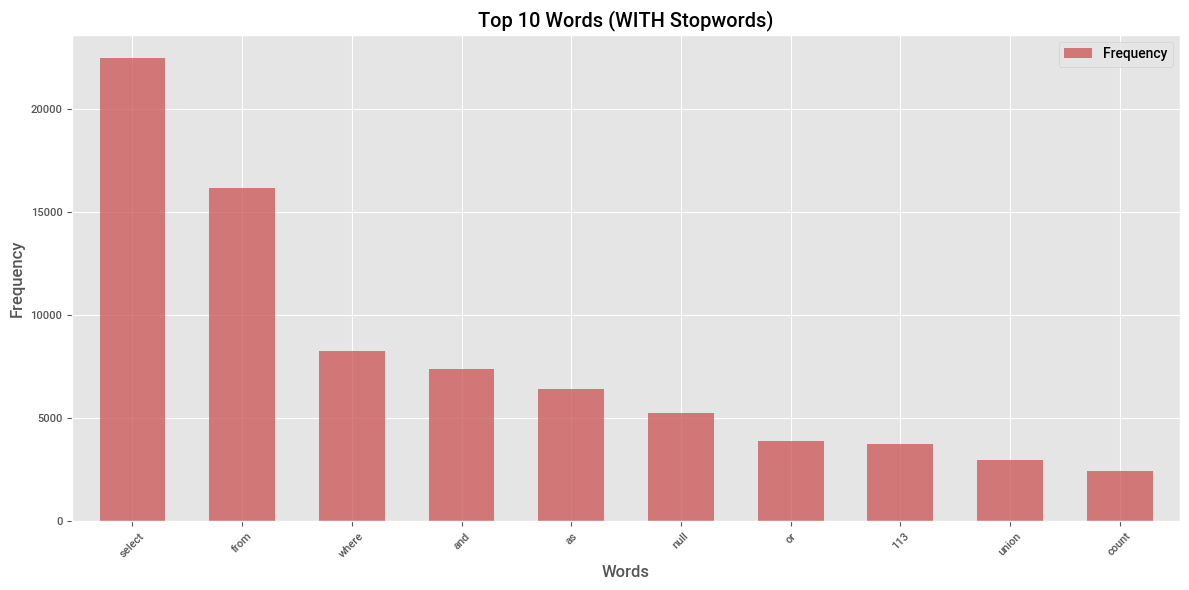

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import nltk

# Download necessary NLTK dictionary for tokenization
nltk.download('punkt')

top_N = 10

print("Processing text and calculating raw frequencies...")

# 1. MERGING AND TOKENIZING
# Convert the entire dataset to lowercase and combine into a single string
# Assuming your dataframe is loaded as 'df'
payloads = df['Sentence'].str.lower().str.replace(r'\|', ' ').str.cat(sep=' ')

# Tokenize the payloads
words = nltk.word_tokenize(payloads)

# Filter out single characters and pure punctuation for a readable raw graph
# We keep the stopwords here!
raw_words = [word for word in words if len(word) > 1 and word.isalnum()]

# 2. FREQUENCY DISTRIBUTION (WITH STOPWORDS)
word_freq_raw = nltk.FreqDist(raw_words)

print("\nTop 10 used words in payloads WITH stop words:")
print('='*80)

result_raw = pd.DataFrame(word_freq_raw.most_common(top_N), columns=['Word', 'Frequency']).set_index('Word')
print(result_raw)

# 3. VISUALIZATION
matplotlib.style.use('ggplot')

# Using a red color to indicate uncleaned/raw data
result_raw.plot.bar(figsize=(12, 6), rot=45, width=0.6, alpha=0.8, color='indianred')

plt.title("Top 10 Words (WITH Stopwords)")
plt.ylabel("Frequency")
plt.xlabel("Words")
plt.tight_layout() # Prevents labels from getting cut off

plt.show()

Applying filters to remove stopwords...

Top 10 used words in payloads WITHOUT stop words:
           Frequency
Word                
count           2425
end             1669
else            1645
case            1601
like            1480
sysusers        1309
all_users       1125
elt             1078
join            1032
rdb             1001


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Mrt\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


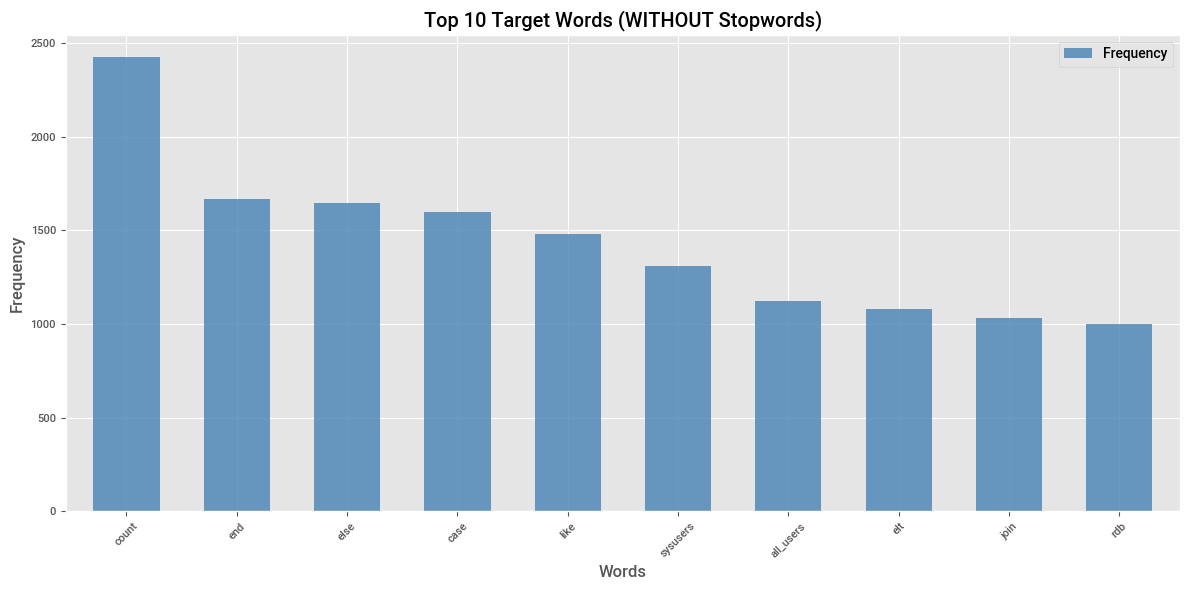

In [29]:
from nltk.corpus import stopwords

# Download necessary NLTK dictionary for stopwords
nltk.download('stopwords')

# 1. PREPARING THE STOPWORDS
# English stopwords and SQL-specific filler words
stop_words = set(stopwords.words('english'))
sql_stopwords = {
    'select', 'from', 'where', 'and', 'or', 'union', 'all', 'by', 'order', 
    'null', 'limit', 'char', 'concat', 'group_concat', 'version', 'cast'
}

print("Applying filters to remove stopwords...")

# 2. THE ULTIMATE FILTER
# Re-using the 'words' list created in Cell 1
# Keep words longer than 1 char, valid identifiers, and exclude all stopwords
cleaned_words = [
    word for word in words 
    if len(word) > 1 
    and word.isidentifier() 
    and word not in stop_words 
    and word not in sql_stopwords
]

# 3. FREQUENCY DISTRIBUTION (WITHOUT STOPWORDS)
word_freq_clean = nltk.FreqDist(cleaned_words)

print("\nTop 10 used words in payloads WITHOUT stop words:")
print('='*80)

result_clean = pd.DataFrame(word_freq_clean.most_common(top_N), columns=['Word', 'Frequency']).set_index('Word')
print(result_clean)

# 4. VISUALIZATION
# Using a blue color to indicate cleaned data
result_clean.plot.bar(figsize=(12, 6), rot=45, width=0.6, alpha=0.8, color='steelblue')

plt.title("Top 10 Target Words (WITHOUT Stopwords)")
plt.ylabel("Frequency")
plt.xlabel("Words")
plt.tight_layout() 

plt.show()